<a href="https://colab.research.google.com/github/dev4v/data-science-portfolio/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#import lstm
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential


In [4]:
import yfinance as yf
import pandas as pd

df = yf.download("GOOG", period="20y")
df.head()

/tmp/ipython-input-4055451330.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GOOG", period="20y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2005-12-02,10.332795,10.378064,10.237804,10.313994,302870996
2005-12-05,10.039658,10.327848,10.000820,10.315479,413118688
2005-12-06,10.007251,10.300883,9.936997,10.110158,607279734
2005-12-07,9.999336,10.060684,9.870454,10.047326,468385066
2005-12-08,10.158397,10.158397,9.960251,10.026052,357735875


In [8]:

# Keep only Close price (for simplicity)
data = df[["Close"]].astype(float)

In [11]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)      # shape: (n_samples, 1)
scaled


array([[0.01249532],
       [0.01157139],
       [0.01146924],
       ...,
       [0.98940966],
       [0.98890534],
       [0.97314598]])

In [12]:
window_size = 3


In [25]:
X = []
y = []

for i in range(window_size, len(scaled)):

    seq_x = scaled[i-window_size : i]

    # next day close price
    seq_y = scaled[i]

    X.append(seq_x)
    y.append(seq_y)


In [14]:
X=np.array(X)
y=np.array(y)

print(X.shape)
print(y.shape)


(5027, 3, 1)
(5027, 1)


In [15]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(32, input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history=model.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0051 - val_loss: 0.0015
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1205e-05 - val_loss: 8.0307e-04
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8669e-05 - val_loss: 6.3437e-04
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4728e-05 - val_loss: 2.9845e-04
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3095e-05 - val_loss: 2.6888e-04
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0919e-05 - val_loss: 2.0094e-04
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1253e-05 - val_loss: 1.7500e-04
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.4885e-06 - val_loss: 1.6693e-04
Epoch 9/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.1843e-06 - val_loss: 1.7324e-04
Epoch 10/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.3266e-06 - val_loss: 1.8178e-04
Epoch 11/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.661

In [18]:
#predictions
y_pred_scaled = model.predict(X_test)
print("Scaled predictions:\n", y_pred_scaled)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Scaled predictions:
 [[0.43279576]
 [0.4322345 ]
 [0.4278154 ]
 ...
 [0.9406057 ]
 [0.9580263 ]
 [0.95931315]]


In [19]:
# reshape y_test and y_pred_scaled if needed
y_test_scaled = y_test.reshape(-1, 1)
y_pred_scaled = y_pred_scaled.reshape(-1, 1)

# inverse transform
y_test_real = scaler.inverse_transform(y_test_scaled)
y_pred_real = scaler.inverse_transform(y_pred_scaled)


In [20]:
for real, pred in zip(y_test_real, y_pred_real):
    print("True:", real[0], "Predicted:", pred[0])


True: 145.12091064453125 Predicted: 143.6822
True: 141.48379516601562 Predicted: 143.50412
True: 140.65545654296875 Predicted: 142.10208
True: 142.7992706298828 Predicted: 141.67897
True: 141.55181884765625 Predicted: 140.96107
True: 142.81915283203125 Predicted: 140.97855
True: 147.0303192138672 Predicted: 141.68794
True: 147.70970153808594 Predicted: 143.13446
True: 147.099365234375 Predicted: 145.16287
True: 147.66448974609375 Predicted: 146.53374
True: 145.70738220214844 Predicted: 146.74303
True: 143.98519897460938 Predicted: 146.06824
True: 146.3668975830078 Predicted: 145.02039
True: 143.8540496826172 Predicted: 144.63217
True: 141.83241271972656 Predicted: 144.00986
True: 141.43362426757812 Predicted: 143.26138
True: 143.24026489257812 Predicted: 141.65007
True: 145.9502410888672 Predicted: 141.48024
True: 146.14242553710938 Predicted: 142.8685
True: 147.05763244628906 Predicted: 144.40988
True: 145.45262145996094 Predicted: 145.65604
True: 145.50875854492188 Predicted: 145.474

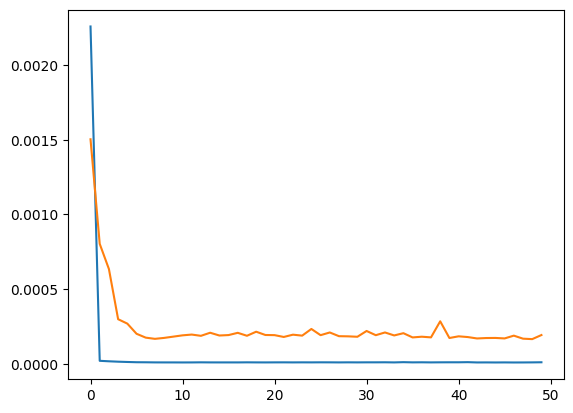

In [21]:
#plot graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

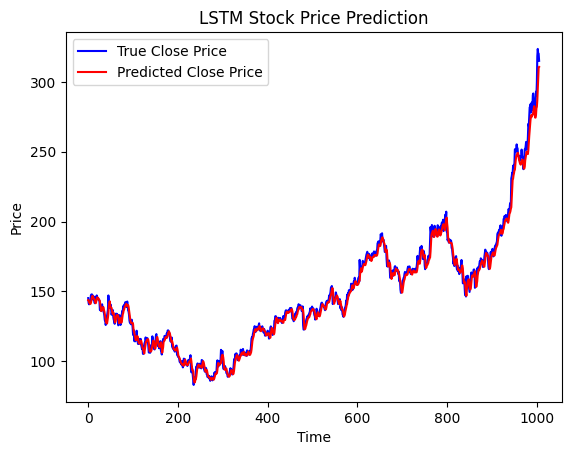

In [23]:
import matplotlib.pyplot as plt

plt.plot(y_test_real, color='blue', label='True Close Price')
plt.plot(y_pred_real, color='red', label='Predicted Close Price')
plt.title('LSTM Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()
